In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
import os
import re
from tqdm import tqdm

import csv
import tkinter as tk
from tkinter import filedialog

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [12]:
def find_spot_center_of_mass_windowed_roi(image_path, N=50, x1=850, x2=1550, threshold_frac=0.2):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be loaded.")
    image = image.astype(np.float64)

    # threshold
    threshold = threshold_frac * np.max(image)
    _, binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    binary = binary.astype(np.uint8)

    # find blobs
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
    if num_labels <= 1:
        _, _, _, max_loc = cv2.minMaxLoc(image)
        return max_loc[0]

    # filter blobs by centroid x between x1 and x2
    valid_labels = [
        i for i in range(1, num_labels) 
        if x1 <= centroids[i][0] <= x2
    ]
    if not valid_labels:
        _, _, _, max_loc = cv2.minMaxLoc(image)
        return max_loc[0]

    # find largest valid blob (by area)
    areas = [(i, stats[i, cv2.CC_STAT_AREA]) for i in valid_labels]
    chosen_label = max(areas, key=lambda x: x[1])[0]

    # find blob centroid
    cx, cy = centroids[chosen_label]
    cx, cy = int(round(cx)), int(round(cy))

    # Get ROI around blob centroid
    half_N = N // 2
    x_start = max(cx - half_N, 0)
    x_end = min(cx + half_N + 1, image.shape[1])
    y_start = max(cy - half_N, 0)
    y_end = min(cy + half_N + 1, image.shape[0])
    roi = image[y_start:y_end, x_start:x_end]

    if np.sum(roi) == 0:
        return cx

    # calc center of mass in ROI and convert back to image coordinates
    y_indices, x_indices = np.indices(roi.shape)
    roi_total = np.sum(roi)
    center_x_roi = np.sum(x_indices * roi) / roi_total
    # Convert to global x coordinate:
    center_x_img = x_start + center_x_roi

    return center_x_img

def find_trend_transitions(x_coords, y_coords):
    transitions = []
    for i in range(1, len(y_coords) - 1):
        if (y_coords[i - 1] < y_coords[i] > y_coords[i + 1]) or (y_coords[i - 1] > y_coords[i] < y_coords[i + 1]):
            transitions.append(i)
    return transitions

def process_directory(directory_path, step=1):
    
    x_coords = []
    y_coords = []

    files = os.listdir(directory_path)
    
    #sort files 
    files.sort()

    # process every `step`-th file.
    for index, filename in tqdm(enumerate(files),
                                desc="Scanning directory",
                                unit="file",
                                total=len(files)):

        if index % step != 0:
            continue  # Skip files based on step

        if not filename.endswith('.bmp'):
            continue

        match = re.search(r'_(\d+)\.0deg', filename)
        if not match:
            continue

        x_coord = int(match.group(1))
        image_path = os.path.join(directory_path, filename)
        y_coord = find_spot_center_of_mass_windowed_roi(image_path,N=50, x1=850, x2=1550, threshold_frac=0.2)

        if y_coord is not None:
            x_coords.append(x_coord)
            y_coords.append(y_coord)

    if not x_coords or not y_coords:
        print("No valid data points found. Unable to plot curve.")
        return

    points = sorted(zip(x_coords, y_coords))
    x_coords, y_coords = zip(*points)
    return x_coords, y_coords

def save_list_to_csv(data_list):
    """
    Prompt the user for a filename/location via a save‐dialog,
    then write data_list to that CSV. Each element of data_list
    can be a list/tuple (one CSV row) or a scalar (becomes a 1-column row).
    """

    root = tk.Tk()
    root.withdraw()


    file_path = filedialog.asksaveasfilename(
        defaultextension=".csv",
        filetypes=[("CSV files", "*.csv"), ("All files", "*.*")],
        title="Save as CSV"
    )

    if not file_path:
        print("Save cancelled.")
        return False

    try:
        with open(file_path, "w", newline="", encoding="utf-8") as csvfile:
            writer = csv.writer(csvfile)
            for row in data_list:
                # If row is iterable, write it directly; else wrap it
                if isinstance(row, (list, tuple)):
                    writer.writerow(row)
                else:
                    writer.writerow([row])
        print(f"Successfully saved CSV to {file_path}")
        return True
    except Exception as e:
        print(f"Error saving CSV: {e}")
        return False
    finally:
        root.destroy()

import matplotlib.pyplot as plt

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

def plot_xy(x_coords, y_coords,
            title="X vs Y",
            xlabel="X coordinate",
            ylabel="Y coordinate",
            x_min=None, x_max=None, y_min=None, y_max=None,
            save_path=None,
            save_as_svg=False,
            fit_line=None,           # optional fit line
            fit_color='red',
            fit_linestyle='--',
            fit_linewidth=3,
            fig_width=6,             # figure width in inches
            fig_height=8):           # figure height in inches

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ["Arial"]
    plt.rcParams['pdf.fonttype'] = 42
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Original data
    ax.plot(x_coords, y_coords, linestyle='-', linewidth=4, color='black')
    
    # Optional fit line
    if fit_line is not None:
        ax.plot(x_coords, fit_line, color=fit_color, linestyle=fit_linestyle, linewidth=fit_linewidth)
    
    ax.set_title(title)
    ax.set_xlabel(xlabel, labelpad=20)
    ax.set_ylabel(ylabel, labelpad=20)
    ax.grid(False)
    ax.tick_params(length=10, width=3)
    ax.tick_params(which='minor', length=5, width=3)
    
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(3)
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    
    if x_min is not None or x_max is not None:
        ax.set_xlim(x_min, x_max)
    if y_min is not None or y_max is not None:
        ax.set_ylim(y_min, y_max)

    # --- Saving logic ---
    if save_path:
        if save_path.endswith('.svg') or save_as_svg:
            if not save_path.endswith('.svg'):
                save_path += '.svg'
            fig.savefig(save_path, format='svg', bbox_inches='tight')
            print(f"Plot saved as SVG to {save_path}")
        else:
            if not save_path.endswith('.pdf'):
                save_path += '.pdf'
            with PdfPages(save_path) as pdf:
                pdf.savefig(fig, bbox_inches='tight', pad_inches=0.05, dpi=600)
            print(f"Plot saved as PDF to {save_path}")

    plt.show()


In [22]:
def angles_to_time(angle_deg, frequency_hz):
    
    #convert phase angles (deg) to time offsets (s)

    angle_deg = np.asarray(angle_deg) 
    times_sec = angle_deg / (360 * frequency_hz)
    return times_sec

def pixel_array_to_mrad_angles(pixel_points, pixel_width, working_distance):
    
    #convert pixels to deflection angles (mrad)
    
    pixel_points = np.asarray(pixel_points)
    min_pixel = np.min(pixel_points)
    max_pixel = np.max(pixel_points)
    center_pixel = (min_pixel + max_pixel) / 2.0

    displacement = (pixel_points - center_pixel) * pixel_width

    angles_rad = np.arctan(displacement / working_distance)
    angles_mrad = angles_rad * 1000 

    return angles_mrad

In [23]:
#directory_path = r'Z:\ReLOAD\Fig3\step_settle_data\reload_4L_3Vpp_2amp_1_raw'
#[x_coords,y_coords]=process_directory(directory_path, step=1)

In [24]:
#save_list_to_csv(x_coords)

In [25]:
#save_list_to_csv(y_coords)

In [26]:
xfilepath=r'G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 4\data\reload_4L_3Vpp_2amp_1_constrained_com_x.csv'
yfilepath=r'G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 4\data\reload_4L_3Vpp_2amp_1_constrained_com_y.csv'

x_coords = np.loadtxt(xfilepath, delimiter=',')
y_coords = np.loadtxt(yfilepath, delimiter=',')

In [27]:
import numpy as np

def rotate_and_reverse_y(x, y, start_index, index_base=0):
    """
    Keep x the same, but rotate and reverse y values.
    """
    y = np.asarray(y)
    n = len(y)
    if index_base == 1:
        start_index -= 1
    start_index = start_index % n

    # rotate y
    y_rot = np.concatenate((y[start_index:], y[:start_index]))

    # reverse y
    y_final = y_rot[::-1]

    return np.asarray(x), y_final

In [28]:
angles_mrad = pixel_array_to_mrad_angles(y_coords, 0.0022, 20)
time=angles_to_time(x_coords, 40000)*10**6

time_rev,angles_mrad_rev= rotate_and_reverse_y(time, angles_mrad, 105)

#plot_xy(time_rev,angles_mrad_rev,
            #title=None,
            #xlabel="time(us)",
            #ylabel="spot angle (mrad)",
            #x_min=10, x_max=13, y_min=None, y_max=None,
            #save_path=r'Z:\ReLOAD\ReLOAD_paper_fig\Fig4\data\step_settle_mrad2.pdf')

In [29]:
lin=np.linspace(0,58,360)

y_spots_int=(angles_mrad_rev-min(angles_mrad_rev))
y_spots=(y_spots_int/max(y_spots_int))*58

Plot saved as PDF to G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 4\assets\step_settle_spots.pdf


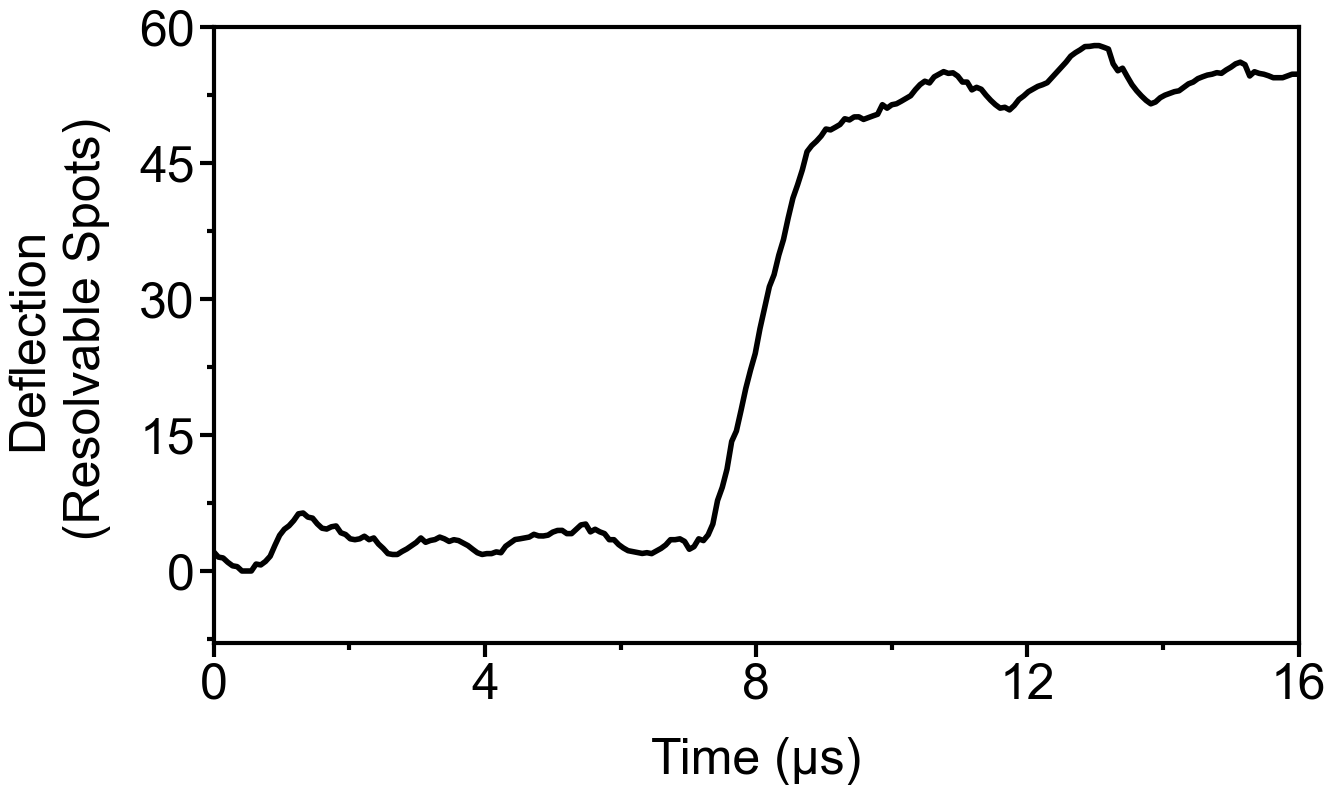

In [37]:
time=angles_to_time(x_coords, 40000)*10**6
#time_rev,spots_y_new= rotate_and_reverse_y(time, y_spots, 105)
plot_xy(time,y_spots,
            title=None,
            ylabel="Deflection \n (Resolvable Spots)",
            xlabel="Time (μs)",
            x_min=0, x_max=16, y_min=-8, y_max=60,
            save_path=r'G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 4\assets\step_settle_spots.pdf',
fit_line=None,           # <-- new argument
fit_color='red',         # color of fit line
fit_linestyle='--',      # style of fit line
fit_linewidth=3,
       fig_width=14,
       fig_height=8)        # width of fit line

In [31]:
spots_s=np.gradient(y_spots, time)

In [33]:
def square_wave(t, t_start, t_end, amplitude, offset):
    """
    Simple rectangular pulse:
    - amplitude: height above offset
    - offset: baseline level
    - t_start: pulse start time
    - t_end: pulse end time
    """
    return np.where((t >= t_start) & (t <= t_end), amplitude + offset, offset)

In [34]:
# Mask data to only 0-15 s
mask = (time >= 0) & (time <= 15)
time_fit = time
spots_fit = spots_s

# Fit only in this region
params, _ = curve_fit(square_wave, time_fit, spots_fit, p0=[7.25, 8.75, 40, 0])

t_start_fit, t_end_fit, amp_fit, offset_fit = params
fit_line = square_wave(time_fit, *params)

# Print fit parameters
print(f"Square wave fit parameters:")
print(f"  t_start = {t_start_fit:.3f} s")
print(f"  t_end   = {t_end_fit:.3f} s")
print(f"  amplitude = {amp_fit:.3f}")
print(f"  offset    = {offset_fit:.3f}")
print(f"  duration  = {t_end_fit - t_start_fit:.3f} s")  # optional

Square wave fit parameters:
  t_start = 7.250 s
  t_end   = 8.750 s
  amplitude = 29.897
  offset    = -1.783
  duration  = 1.500 s


C:\Users\warke\Anaconda3\envs\eodenv\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Plot saved as PDF to G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 4\assets\step_settle_spots_der_fit.pdf


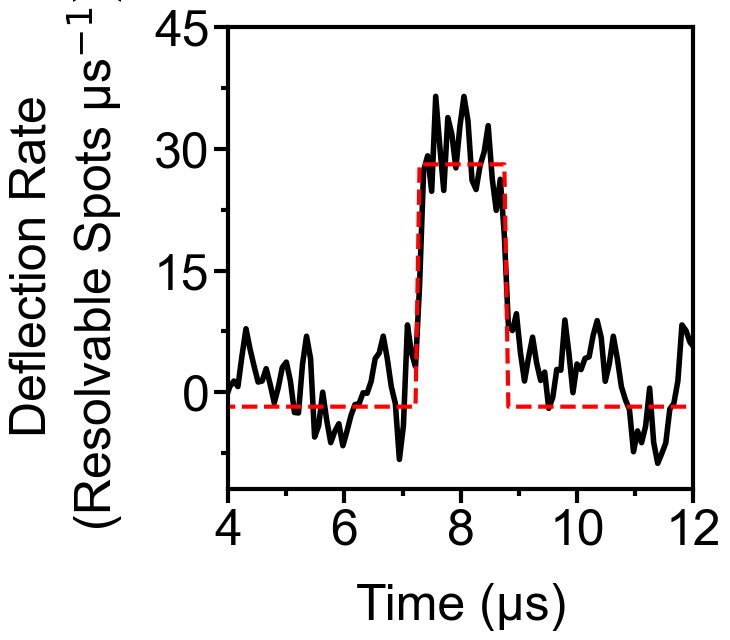

In [38]:
plot_xy(time,spots_s,
            title=None,
            xlabel="Time (μs)",
            ylabel="Deflection Rate \n(Resolvable Spots μs$^{-1}$)",
            x_min=4 ,x_max=12, y_min=-12, y_max=45,
            save_path=r'G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 4\assets\step_settle_spots_der_fit.pdf',
fit_line=fit_line,           # <-- new argument
fit_color='red',         # color of fit line
fit_linestyle='--',      # style of fit line
fit_linewidth=3,
       fig_width=6,
       fig_height=6)        # width of fit line